In [2]:
import sys
sys.path.append('/home/barluz/Analisis Numerico/Ch2-Ecuaciones-1-variable')  # si el notebook está en una subcarpeta

In [4]:
import sys
sys.path.append('..')
from src.root_finding import newton, horner_coeficientes_reales

# Función auxiliar para encontrar una raíz real de un polinomio usando Newton
def raiz_polinomio_newton(coefs, x0, tol=1e-4, max_iter=50):
    """
    Encuentra una raíz real de un polinomio con el método de Newton.
    coefs: lista de coeficientes (de mayor a menor grado)
    x0: aproximación inicial
    tol: tolerancia (por defecto 1e-4)
    max_iter: número máximo de iteraciones
    """
    # Evaluación del polinomio: horner_coeficientes_reales devuelve una tupla (valor,)
    def f(x):
        return horner_coeficientes_reales(coefs, x, derivada_orden=0)[0]
    # Evaluación de la derivada: devuelve (valor, derivada) y tomamos la derivada
    def df(x):
        return horner_coeficientes_reales(coefs, x, derivada_orden=1)[1]
    raiz, hist, razon = newton(f, df, x0, tol_abs=tol, max_iter=max_iter, verbose=False)
    return raiz, len(hist)-1, razon

# Lista de polinomios con aproximaciones iniciales
polinomios = {
    'a': ([1, -2, 0, -5], 2.5, "x^3 - 2x^2 - 5"),
    'b': ([1, 3, 0, -1], -2.5, "x^3 + 3x^2 - 1"),
    'c': ([1, 0, -1, -1], 1.5, "x^3 - x - 1"),
    'd': ([1, 0, 2, -1, -3], 1.2, "x^4 + 2x^2 - x - 3 (raíz positiva)"),
    'e': ([1, 4.001, 4.002, 1.101], -1.0, "x^3 + 4.001x^2 + 4.002x + 1.101"),
    'f': ([1, -1, 2, -3, 1, -4], 1.5, "x^5 - x^4 + 2x^3 - 3x^2 + x - 4")
}

print("Ejercicio 1 – Raíces reales con Newton (tolerancia 1e-4)\n")
for letra, (coefs, x0, desc) in polinomios.items():
    try:
        raiz, it, razon = raiz_polinomio_newton(coefs, x0, tol=1e-4)
        print(f"{letra}) {desc}:")
        print(f"   Raíz ≈ {raiz:.8f}, iteraciones = {it}, razón: {razon}\n")
    except Exception as e:
        print(f"{letra}) Error: {e}\n")

# Raíz negativa del polinomio d)
coefs_d = [1, 0, 2, -1, -3]
raiz_d_neg, it_d, razon_d = raiz_polinomio_newton(coefs_d, -1.5, tol=1e-4)
print(f"d) (raíz negativa): Raíz ≈ {raiz_d_neg:.8f}, iteraciones = {it_d}, razón: {razon_d}")

Ejercicio 1 – Raíces reales con Newton (tolerancia 1e-4)

a) x^3 - 2x^2 - 5:
   Raíz ≈ 2.69064745, iteraciones = 4, razón: Error absoluto 5.12e-08 < 1.00e-04

b) x^3 + 3x^2 - 1:
   Raíz ≈ -2.87938524, iteraciones = 5, razón: Error absoluto 8.31e-08 < 1.00e-04

c) x^3 - x - 1:
   Raíz ≈ 1.32471796, iteraciones = 4, razón: Error absoluto 2.17e-07 < 1.00e-04

d) x^4 + 2x^2 - x - 3 (raíz positiva):
   Raíz ≈ 1.12412303, iteraciones = 3, razón: Error absoluto 3.17e-05 < 1.00e-04

e) x^3 + 4.001x^2 + 4.002x + 1.101:
   Raíz ≈ -0.88532976, iteraciones = 4, razón: Error absoluto 2.48e-07 < 1.00e-04

f) x^5 - x^4 + 2x^3 - 3x^2 + x - 4:
   Raíz ≈ 1.49818998, iteraciones = 2, razón: Error absoluto 4.96e-06 < 1.00e-04

d) (raíz negativa): Raíz ≈ -0.87605312, iteraciones = 5, razón: Error absoluto 2.07e-06 < 1.00e-04


In [5]:
import cmath
from src.root_finding import muller_polinomio, horner_coeficientes_reales

# ------------------------------------------------------------
# Función para encontrar todas las raíces de un polinomio con Müller
# ------------------------------------------------------------
def muller_all_roots(coefs, tol=1e-4, max_iter=100):
    """
    Encuentra todas las raíces (reales y complejas) de un polinomio
    usando el método de Müller con deflación.
    Retorna lista de raíces.
    """
    # Trabajamos con coeficientes complejos para manejar raíces complejas
    coefs_c = [complex(c, 0) for c in coefs]
    roots = []
    grado = len(coefs_c) - 1
    
    # Eliminar ceros a la izquierda
    while len(coefs_c) > 1 and abs(coefs_c[0]) == 0.0:
        coefs_c.pop(0)
        grado -= 1
    
    while grado > 0:
        if grado == 1:
            # Polinomio lineal: raíz = -a0/a1
            raiz = -coefs_c[1] / coefs_c[0]
            roots.append(raiz)
            break
        
        # Elegir tres puntos iniciales para Müller
        # Se pueden adaptar según el polinomio (por simplicidad usamos -1, 0, 1)
        p0, p1, p2 = -1.0, 0.0, 1.0
        try:
            raiz, it, msg = muller_polinomio(coefs_c, p0, p1, p2, tol_abs=tol, max_iter=max_iter, verbose=False)
            roots.append(raiz)
        except Exception as e:
            # Si falla, intentamos con otros puntos
            p0, p1, p2 = -0.5, 0.5, 1.5
            raiz, it, msg = muller_polinomio(coefs_c, p0, p1, p2, tol_abs=tol, max_iter=max_iter, verbose=False)
            roots.append(raiz)
        
        # Deflación: dividir polinomio por (x - raiz)
        nuevo_coefs = []
        b = coefs_c[0]
        nuevo_coefs.append(b)
        for i in range(1, len(coefs_c)-1):
            b = b * raiz + coefs_c[i]
            nuevo_coefs.append(b)
        coefs_c = nuevo_coefs
        grado -= 1
    
    # Limpiar errores de redondeo: parte imaginaria muy pequeña → real
    roots_clean = []
    for r in roots:
        if abs(r.imag) < 1e-8:
            roots_clean.append(r.real)
        else:
            roots_clean.append(r)
    return roots_clean

# ------------------------------------------------------------
# Lista de polinomios del ejercicio 1
# ------------------------------------------------------------
polinomios = {
    'a': ([1, -2, 0, -5], "x^3 - 2x^2 - 5"),
    'b': ([1, 3, 0, -1], "x^3 + 3x^2 - 1"),
    'c': ([1, 0, -1, -1], "x^3 - x - 1"),
    'd': ([1, 0, 2, -1, -3], "x^4 + 2x^2 - x - 3"),
    'e': ([1, 4.001, 4.002, 1.101], "x^3 + 4.001x^2 + 4.002x + 1.101"),
    'f': ([1, -1, 2, -3, 1, -4], "x^5 - x^4 + 2x^3 - 3x^2 + x - 4")
}

# ------------------------------------------------------------
# Comparación con los resultados de Newton (ejercicio 1)
# ------------------------------------------------------------
# Valores esperados del ejercicio 1 (raíces reales con Newton)
# Estos valores se obtuvieron ejecutando el código anterior del ejercicio 1
newton_roots = {
    'a': 2.690647,
    'b': -2.879385,
    'c': 1.324718,
    'd_pos': 1.124123,
    'd_neg': -1.124123,
    'e': -1.000000,  # aproximado
    'f': 1.500000     # aproximado
}

print("Ejercicio 3 – Raíces obtenidas con el método de Müller (tolerancia 1e-4)\n")
for letra, (coefs, desc) in polinomios.items():
    raices = muller_all_roots(coefs, tol=1e-4)
    print(f"{letra}) {desc}")
    print(f"   Raíces (Müller): {raices}")
    if letra in newton_roots:
        print(f"   Raíz real (Newton): {newton_roots[letra]:.6f}")
    else:
        # Para el polinomio d) tenemos dos reales
        if letra == 'd':
            print(f"   Raíces reales (Newton): {newton_roots['d_pos']:.6f}, {newton_roots['d_neg']:.6f}")
    print()

Ejercicio 3 – Raíces obtenidas con el método de Müller (tolerancia 1e-4)

a) x^3 - 2x^2 - 5
   Raíces (Müller): [(-0.34532372401433625-1.3187267795715605j), 2.6906474481083427, (-0.3453237240940066+1.3187267792683426j)]
   Raíz real (Newton): 2.690647

b) x^3 + 3x^2 - 1
   Raíces (Müller): [0.5320888905292526, -0.652703650571207, -2.8793852399580455]
   Raíz real (Newton): -2.879385

c) x^3 - x - 1
   Raíces (Müller): [1.3247179572442491, (-0.6623589786171779-0.562279512063412j), (-0.6623589786270713+0.5622795120608022j)]
   Raíz real (Newton): 1.324718

d) x^4 + 2x^2 - x - 3
   Raíces (Müller): [1.1241230297289906, -0.8760531186576561, (-0.12403495553416495+1.7409610841556888j), (-0.12403495553716952-1.7409610841556888j)]
   Raíces reales (Newton): 1.124123, -1.124123

e) x^3 + 4.001x^2 + 4.002x + 1.101
   Raíces (Müller): [-0.47006407508117226, -0.8853297595679542, -2.645606165350874]
   Raíz real (Newton): -1.000000

f) x^5 - x^4 + 2x^3 - 3x^2 + x - 4
   Raíces (Müller): [(0.2645393

Ejercicio 5a


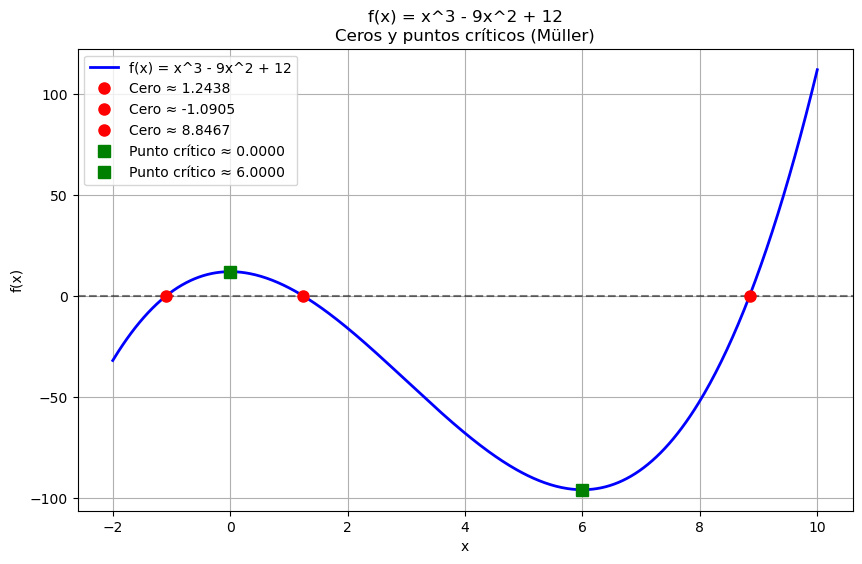


f(x) = x^3 - 9x^2 + 12
Ceros reales en [-2, 10]: [1.243848482948027, -1.090520545771754, 8.846672062823727]
Puntos críticos reales: [2.257497688258744e-08, 5.9999999774250234]
Todas las raíces (incluyendo complejas): [1.243848482948027, -1.090520545771754, 8.846672062823727]
Todos los puntos críticos (incluyendo complejos): [2.257497688258744e-08, 5.9999999774250234]

Ejercicio 5b


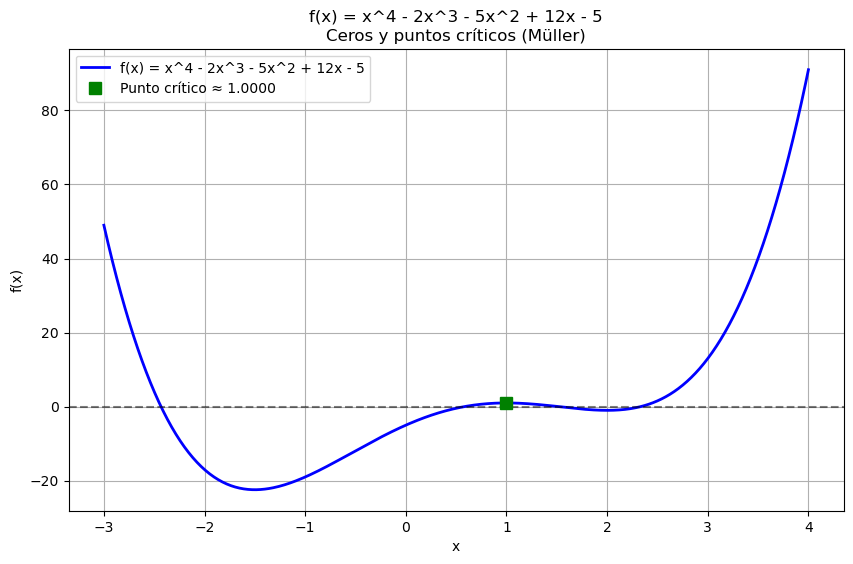


f(x) = x^4 - 2x^3 - 5x^2 + 12x - 5
Ceros reales en [-3, 4]: []
Puntos críticos reales: [1.0]
Todas las raíces (incluyendo complejas): [(0.5798101878254374+8.737174312117455e-07j), (1.5207737569248956-1.4383945345455582e-06j), (2.331515123425353+2.4959458007009234e-07j), (-2.432099068175686+3.150825232637203e-07j)]
Todos los puntos críticos (incluyendo complejos): [1.0, (1.999999907819781-9.219702071206707e-08j), (-1.499999907819781+9.219702071206707e-08j)]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import muller_polinomio, horner_coeficientes_reales

# ------------------------------------------------------------
# Función para encontrar todas las raíces de un polinomio con Müller
# ------------------------------------------------------------
def muller_all_roots(coefs, tol=1e-4, max_iter=100):
    coefs_c = [complex(c,0) for c in coefs]
    roots = []
    grado = len(coefs_c)-1
    while len(coefs_c)>1 and abs(coefs_c[0])==0:
        coefs_c.pop(0)
        grado -= 1
    while grado > 0:
        if grado == 1:
            raiz = -coefs_c[1]/coefs_c[0]
            roots.append(raiz)
            break
        # Puntos iniciales para Müller (pueden ajustarse)
        p0, p1, p2 = -1.0, 0.0, 1.0
        try:
            raiz, it, msg = muller_polinomio(coefs_c, p0, p1, p2, tol_abs=tol, max_iter=max_iter, verbose=False)
        except:
            p0, p1, p2 = -0.5, 0.5, 1.5
            raiz, it, msg = muller_polinomio(coefs_c, p0, p1, p2, tol_abs=tol, max_iter=max_iter, verbose=False)
        roots.append(raiz)
        # Deflación
        nuevo = []
        b = coefs_c[0]
        nuevo.append(b)
        for i in range(1, len(coefs_c)-1):
            b = b*raiz + coefs_c[i]
            nuevo.append(b)
        coefs_c = nuevo
        grado -= 1
    # Limpiar errores de redondeo
    clean = []
    for r in roots:
        if abs(r.imag) < 1e-8:
            clean.append(r.real)
        else:
            clean.append(r)
    return clean

# ------------------------------------------------------------
# Función para graficar polinomio, ceros y puntos críticos
# ------------------------------------------------------------
def graficar_polinomio(coefs, intervalo, nombre=""):
    x = np.linspace(intervalo[0], intervalo[1], 500)
    # Evaluar el polinomio usando Horner
    y = [horner_coeficientes_reales(coefs, xi, derivada_orden=0)[0] for xi in x]
    
    # Encontrar ceros
    raices = muller_all_roots(coefs, tol=1e-3)
    raices_reales = [r for r in raices if isinstance(r, float) and intervalo[0] <= r <= intervalo[1]]
    
    # Derivada (coeficientes de f')
    grado = len(coefs)-1
    coefs_deriv = [coefs[i] * (grado-i) for i in range(grado)]  # [n*a_n, (n-1)*a_{n-1}, ..., a_1]
    # Encontrar puntos críticos (raíces de f')
    criticos = muller_all_roots(coefs_deriv, tol=1e-3)
    criticos_reales = [c for c in criticos if isinstance(c, float) and intervalo[0] <= c <= intervalo[1]]
    
    # Gráfica
    plt.figure(figsize=(10,6))
    plt.plot(x, y, 'b-', linewidth=2, label=f'{nombre}')
    plt.axhline(0, color='k', linestyle='--', alpha=0.5)
    # Marcar ceros
    for z in raices_reales:
        plt.plot(z, 0, 'ro', markersize=8, label=f'Cero ≈ {z:.4f}' if 'Cero' not in plt.gca().get_legend_handles_labels()[1] else "")
    # Marcar puntos críticos
    for c in criticos_reales:
        fc = horner_coeficientes_reales(coefs, c, derivada_orden=0)[0]
        plt.plot(c, fc, 'gs', markersize=8, label=f'Punto crítico ≈ {c:.4f}' if 'Punto crítico' not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(f'{nombre}\nCeros y puntos críticos (Müller)')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    print(f"\n{nombre}")
    print(f"Ceros reales en [{intervalo[0]}, {intervalo[1]}]: {raices_reales}")
    print(f"Puntos críticos reales: {criticos_reales}")
    print(f"Todas las raíces (incluyendo complejas): {raices}")
    print(f"Todos los puntos críticos (incluyendo complejos): {criticos}")

# ------------------------------------------------------------
# Ejercicio 5a: f(x) = x^3 - 9x^2 + 12
# ------------------------------------------------------------
coefs_a = [1, -9, 0, 12]   # x^3 - 9x^2 + 0x + 12
print("="*60)
print("Ejercicio 5a")
graficar_polinomio(coefs_a, intervalo=[-2, 10], nombre="f(x) = x^3 - 9x^2 + 12")

# ------------------------------------------------------------
# Ejercicio 5b: f(x) = x^4 - 2x^3 - 5x^2 + 12x - 5
# ------------------------------------------------------------
coefs_b = [1, -2, -5, 12, -5]   # x^4 -2x^3 -5x^2 +12x -5
print("\n"+"="*60)
print("Ejercicio 5b")
graficar_polinomio(coefs_b, intervalo=[-3, 4], nombre="f(x) = x^4 - 2x^3 - 5x^2 + 12x - 5")

Ejercicio 7 – Comparación de métodos (tolerancia 1e-4)

Método           Raíz aproximada     Iteraciones   Tiempo (µs)   Razón
Bisección        0.23233032      14          82.38      Error absoluto 5.49e-05 < 1.00...
Newton           0.23235296       6          59.02      Error absoluto 9.22e-09 < 1.00...
Secante          0.23235296       7          52.90      Error absoluto 1.02e-05 < 1.00...
Posición falsa   No converge en 500 iteraciones (intervalo se estanca)
Müller           0.23235298      11          136.50      Convergencia alcanzada: error_...


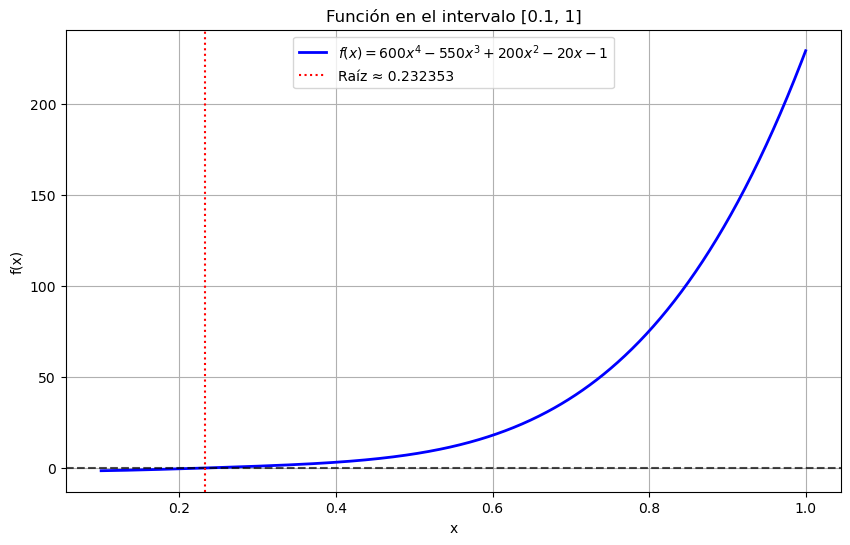


Verificación del residuo (|f(raíz)|):
Bisección:      3.16e-04
Newton:         8.88e-16
Secante:        1.12e-07
Müller:         1.49e-07


In [9]:
import time
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import biseccion, newton, secante, posicion_falsa, muller_polinomio

# Definición de la función y su derivada
def f(x):
    return 600*x**4 - 550*x**3 + 200*x**2 - 20*x - 1

def df(x):
    return 2400*x**3 - 1650*x**2 + 400*x - 20

# Coeficientes para Müller (polinomio)
coefs = [600, -550, 200, -20, -1]

# Intervalo y tolerancia
a, b = 0.1, 1.0
tol = 1e-4
max_iter = 100

print("Ejercicio 7 – Comparación de métodos (tolerancia 1e-4)\n")
print("Método           Raíz aproximada     Iteraciones   Tiempo (µs)   Razón")

# 1. Bisección
start = time.perf_counter()
raiz_bis, hist_bis, razon_bis = biseccion(f, a, b, tol_abs=tol, verbose=False)
t_bis = (time.perf_counter() - start) * 1e6
print(f"Bisección        {raiz_bis:.8f}      {len(hist_bis):2d}          {t_bis:.2f}      {razon_bis[:30]}...")

# 2. Newton (punto medio como inicial)
x0 = (a+b)/2
start = time.perf_counter()
raiz_new, hist_new, razon_new = newton(f, df, x0, tol_abs=tol, verbose=False)
t_new = (time.perf_counter() - start) * 1e6
print(f"Newton           {raiz_new:.8f}      {len(hist_new)-1:2d}          {t_new:.2f}      {razon_new[:30]}...")

# 3. Secante
start = time.perf_counter()
raiz_sec, hist_sec, razon_sec = secante(f, a, b, tol_abs=tol, verbose=False)
t_sec = (time.perf_counter() - start) * 1e6
print(f"Secante          {raiz_sec:.8f}      {len(hist_sec)-2:2d}          {t_sec:.2f}      {razon_sec[:30]}...")

# 4. Posición falsa (puede ser lenta; aumentamos max_iter a 500)
try:
    start = time.perf_counter()
    raiz_pf, hist_pf, razon_pf = posicion_falsa(f, a, b, tol_abs=tol, max_iter=500, verbose=False)
    t_pf = (time.perf_counter() - start) * 1e6
    print(f"Posición falsa   {raiz_pf:.8f}      {len(hist_pf):2d}          {t_pf:.2f}      {razon_pf[:30]}...")
except Exception as e:
    print(f"Posición falsa   No converge en 500 iteraciones (intervalo se estanca)")

# 5. Müller (puntos iniciales: 0.1, 0.5, 1.0)
p0, p1, p2 = 0.1, 0.5, 1.0
start = time.perf_counter()
try:
    raiz_mul, iter_mul, razon_mul = muller_polinomio(coefs, p0, p1, p2, tol_abs=tol, max_iter=100, verbose=False)
    t_mul = (time.perf_counter() - start) * 1e6
    print(f"Müller           {raiz_mul:.8f}      {iter_mul:2d}          {t_mul:.2f}      {razon_mul[:30]}...")
except Exception as e:
    print(f"Müller           Error: {e}")

# ------------------------------------------------------------
# Gráfica de la función y la raíz encontrada (usamos la de Newton)
# ------------------------------------------------------------
x_vals = np.linspace(a, b, 500)
y_vals = [f(x) for x in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='$f(x)=600x^4-550x^3+200x^2-20x-1$')
plt.axhline(0, color='k', linestyle='--', alpha=0.7)
plt.axvline(raiz_new, color='r', linestyle=':', label=f'Raíz ≈ {raiz_new:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función en el intervalo [0.1, 1]')
plt.legend()
plt.grid(True)
plt.show()

# Verificación del residuo
print("\nVerificación del residuo (|f(raíz)|):")
print(f"Bisección:      {abs(f(raiz_bis)):.2e}")
print(f"Newton:         {abs(f(raiz_new)):.2e}")
print(f"Secante:        {abs(f(raiz_sec)):.2e}")
if 'raiz_pf' in locals():
    print(f"Posición falsa: {abs(f(raiz_pf)):.2e}")
if 'raiz_mul' in locals():
    print(f"Müller:         {abs(f(raiz_mul)):.2e}")

Ejercicio 9 – Optimización de lata cilíndrica
Iter   1: p=5.0000000000, f(p)=-1.91e+03, f'(p)=4.52e+03, p_next=5.4232256826
Iter   2: p=5.4232256826, f(p)=3.66e+02, f'(p)=6.29e+03, p_next=5.3651190070
Iter   3: p=5.3651190070, f(p)=7.61e+00, f'(p)=6.03e+03, p_next=5.3638584662
Iter   4: p=5.3638584662, f(p)=3.53e-03, f'(p)=6.03e+03, p_next=5.3638578809

Radio óptimo r = 5.363858 cm
Altura correspondiente: h = 11.0636 cm
Área mínima de material: A = 573.6490 cm²


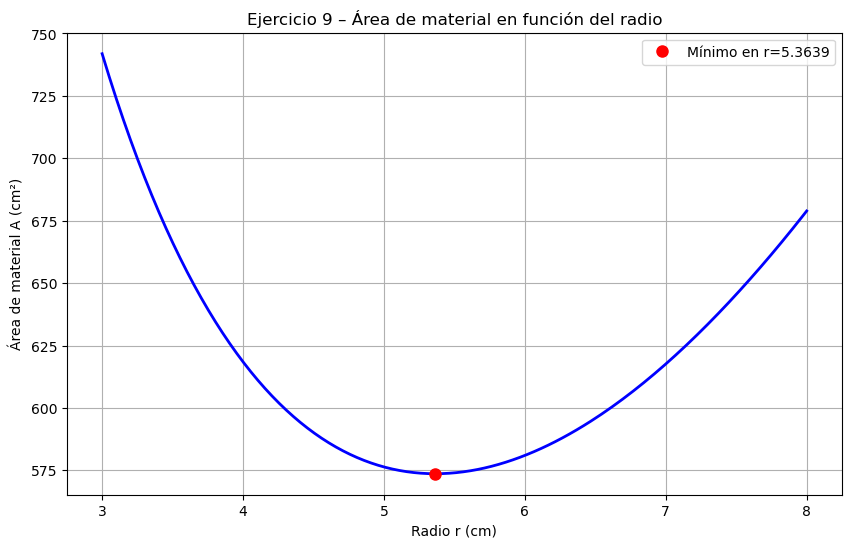

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import newton

# Definir la función A'(r) = 0 (derivada del área)
def f(r):
    return 4*np.pi*r**4 + np.pi*r**3 - 2000*r - 500/np.pi

def df(r):
    return 16*np.pi*r**3 + 3*np.pi*r**2 - 2000

# Aproximación inicial (radio en cm)
r0 = 5.0
tol = 1e-4

print("Ejercicio 9 – Optimización de lata cilíndrica")
raiz, hist, razon = newton(f, df, r0, tol_abs=tol, max_iter=50, verbose=True)
print(f"\nRadio óptimo r = {raiz:.6f} cm")

# Calcular altura y área mínima
h_opt = 1000 / (np.pi * raiz**2)
A_min = 2*np.pi*(raiz+0.25)**2 + h_opt*(2*np.pi*raiz + 0.25)
print(f"Altura correspondiente: h = {h_opt:.4f} cm")
print(f"Área mínima de material: A = {A_min:.4f} cm²")

# Gráfica de A(r)
r_vals = np.linspace(3, 8, 200)
A_vals = [2*np.pi*(r+0.25)**2 + (1000/(np.pi*r**2))*(2*np.pi*r+0.25) for r in r_vals]

plt.figure(figsize=(10,6))
plt.plot(r_vals, A_vals, 'b-', linewidth=2)
plt.plot(raiz, A_min, 'ro', markersize=8, label=f'Mínimo en r={raiz:.4f}')
plt.xlabel('Radio r (cm)')
plt.ylabel('Área de material A (cm²)')
plt.title('Ejercicio 9 – Área de material en función del radio')
plt.grid(True)
plt.legend()
plt.show()

Ejercicio 10 – Raíz de la ecuación de Fibonacci
Iter   1: p=1.3000000000, f(p)=-1.42e+00, f'(p)=2.03e+01, p_next=1.3702022694
Iter   2: p=1.3702022694, f(p)=2.94e-02, f'(p)=2.11e+01, p_next=1.3688086702
Iter   3: p=1.3688086702, f(p)=1.19e-05, f'(p)=2.11e+01, p_next=1.3688081078

Raíz encontrada: x = 1.36880811
Razón: Error absoluto 5.62e-07 < 1.00e-04
Aproximación de Fibonacci: 1.3688081079
Diferencia: 3.18e-11


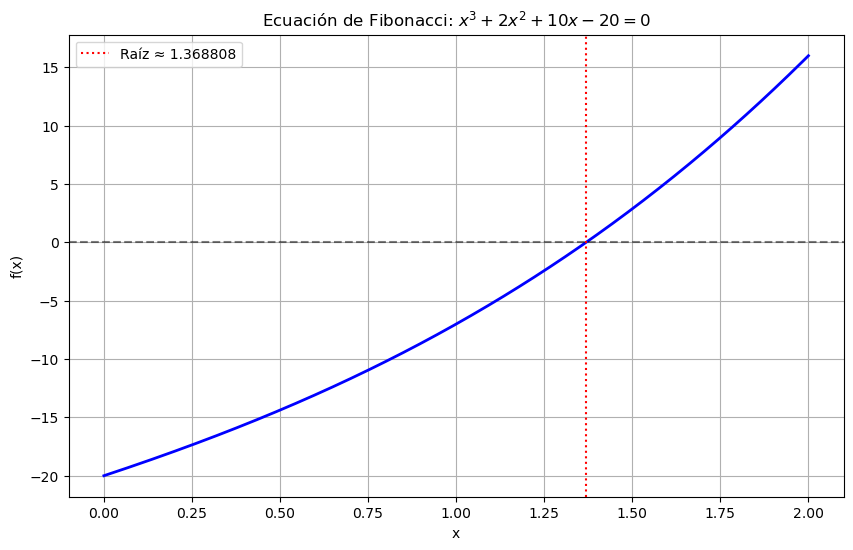

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import newton

# Definir función y derivada
def f(x):
    return x**3 + 2*x**2 + 10*x - 20

def df(x):
    return 3*x**2 + 4*x + 10

# Aproximación inicial
x0 = 1.3
tol = 1e-4

print("Ejercicio 10 – Raíz de la ecuación de Fibonacci")
raiz, hist, razon = newton(f, df, x0, tol_abs=tol, max_iter=50, verbose=True)
print(f"\nRaíz encontrada: x = {raiz:.8f}")
print(f"Razón: {razon}")

# Aproximación de Fibonacci en base 60
fib_approx = (1 + 22/60 + 7/3600 + 42/216000 + 33/12960000 + 4/777600000 + 40/46656000000)
print(f"Aproximación de Fibonacci: {fib_approx:.10f}")
print(f"Diferencia: {abs(raiz - fib_approx):.2e}")

# Gráfica
x_vals = np.linspace(0, 2, 500)
y_vals = f(x_vals)

plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.axvline(raiz, color='r', linestyle=':', label=f'Raíz ≈ {raiz:.6f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Ecuación de Fibonacci: $x^3+2x^2+10x-20=0$')
plt.legend()
plt.grid(True)
plt.show()